In [57]:
import pandas as pd
import numpy as np
import spacy
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import os
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [58]:
df = pd.read_csv('../data/comentarios_toxicos_ptBR.csv')
df.dropna(subset=['text', 'toxic'], inplace=True)
df.head()

,Unnamed: 0,text,text_norm,toxic
0,12451,brocolis é muito boooom pqp,brócolis boom puta pariu,0
1,4080,to correndo disso,to correndo disso,0
2,5195,presidente da oab sofre amea莽as de morte e aci...,presidente aba sofre ame-a morte aciona polega...,0
3,13375,@user @user aí desanima pq para de vir teus ch...,aí desanima porque vir champ chato pra caralho...,1
4,4130,"ser feio e beta é um bosta, puta que me pariu....",feio beta bosta puta pariu lá vou comprar ócul...,1


In [59]:
nlp = spacy.load("pt_core_news_sm")

def preProcessar(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-záéíóúâêôãõüç\s]', '', texto)
    doc = nlp(texto)
    return [token.text for token in doc if not token.is_stop and token.text.strip()]

print("Processando textos (isso pode demorar alguns minutos)...")
if 'text_norm' in df.columns:
    df.dropna(subset=['text_norm'], inplace=True)
    df['text_normalized'] = df['text_norm'].apply(lambda x: x.split())
else:
    df['text_normalized'] = df['text'].apply(preProcessar)

df['text_normalized_str'] = df['text_normalized'].apply(lambda x: ' '.join(x))
df[['text', 'text_normalized_str', 'toxic']].head()

Processando textos (isso pode demorar alguns minutos)...


,text,text_normalized_str,toxic
0,brocolis é muito boooom pqp,brócolis boom puta pariu,0
1,to correndo disso,to correndo disso,0
2,presidente da oab sofre amea莽as de morte e aci...,presidente aba sofre ame-a morte aciona polega...,0
3,@user @user aí desanima pq para de vir teus ch...,aí desanima porque vir champ chato pra caralho...,1
4,"ser feio e beta é um bosta, puta que me pariu....",feio beta bosta puta pariu lá vou comprar ócul...,1


In [60]:
X = df['text_normalized_str']
y = df['toxic']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.10, random_state=42, stratify=y_train_full
)

print("Treino:", len(X_train))
print("Validação:", len(X_val))
print("Teste:", len(X_test))

Treino: 24192
Validação: 2689
Teste: 2987


In [61]:
MAX_WORDS = 20000

tokenizer_rnn = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer_rnn.fit_on_texts(X_train)

print("Tamanho do vocabulário:", len(tokenizer_rnn.word_index))

Tamanho do vocabulário: 40555


In [62]:
MAX_LEN = 100

X_train_seq = tokenizer_rnn.texts_to_sequences(X_train)
X_val_seq = tokenizer_rnn.texts_to_sequences(X_val)
X_test_seq = tokenizer_rnn.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

In [63]:
vocab_size = min(MAX_WORDS, len(tokenizer_rnn.word_index) + 1)

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128),
    LSTM(64, dropout=0.3, recurrent_dropout=0.3),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [64]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

os.makedirs('../models', exist_ok=True)
checkpoint = ModelCheckpoint(
    '../models/rnn_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [65]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Epoch 1/15


378/378 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - accuracy: 0.5730 - loss: 0.6766 - val_accuracy: 0.5787 - val_loss: 0.6653
Epoch 2/15
378/378 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.6212 - loss: 0.6349 - val_accuracy: 0.7445 - val_loss: 0.5289
Epoch 3/15
378/378 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.7872 - loss: 0.4608 - val_accuracy: 0.7992 - val_loss: 0.4243
Epoch 4/15
378/378 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.8467 - loss: 0.3545 - val_accuracy: 0.7869 - val_loss: 0.4386
Epoch 5/15
378/378 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.8800 - loss: 0.2880 - val_accuracy: 0.7795 - val_loss: 0.5172
Epoch 6/15
378/378 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.9019 - loss: 0.2383 - val_accuracy: 0.7728 - val_loss: 0.5483


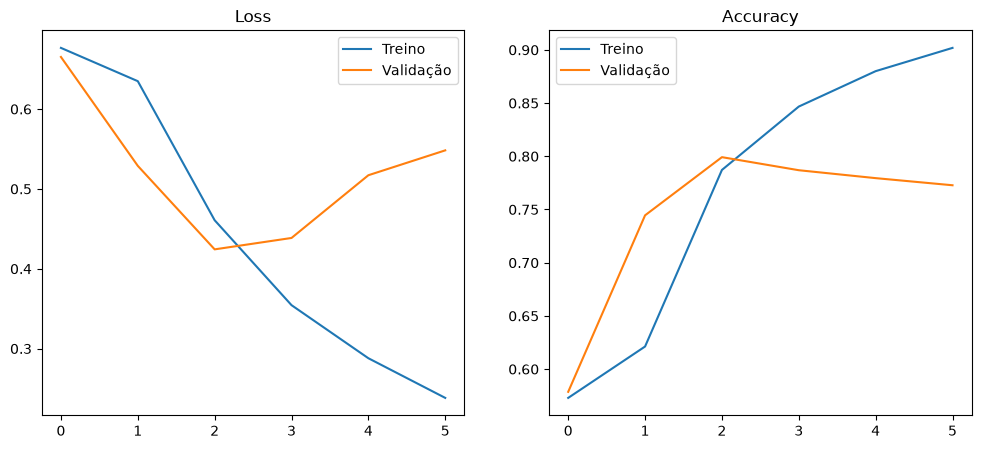

In [66]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Accuracy')
plt.legend()

plt.show()

In [67]:
results = model.evaluate(X_test_pad, y_test, verbose=1)
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8008 - loss: 0.4256
loss: 0.4256
compile_metrics: 0.8008


              precision    recall  f1-score   support

  Não Tóxico       0.84      0.79      0.81      1636
      Tóxico       0.76      0.81      0.79      1351

    accuracy                           0.80      2987
   macro avg       0.80      0.80      0.80      2987
weighted avg       0.80      0.80      0.80      2987



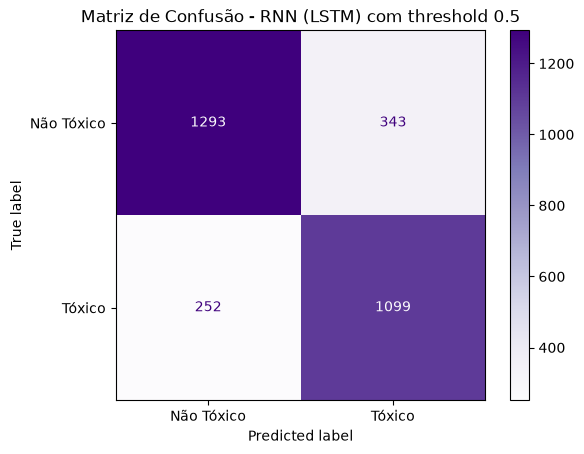

In [68]:
y_prob = model.predict(X_test_pad, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Não Tóxico', 'Tóxico']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Tóxico', 'Tóxico'])
disp.plot(cmap=plt.cm.Purples)
plt.title('Matriz de Confusão - RNN (LSTM) com threshold 0.5')
plt.show()

Threshold ótimo (máximo F1): 0.3258
F1: 0.7971 | Precisão: 0.7219 | Recall: 0.8897
              precision    recall  f1-score   support

  Não Tóxico       0.89      0.72      0.79      1636
      Tóxico       0.72      0.89      0.80      1351

    accuracy                           0.80      2987
   macro avg       0.80      0.80      0.80      2987
weighted avg       0.81      0.80      0.79      2987

Tóxicos retidos no threshold 0.5: 1099/1351 (81.3%)
Tóxicos retidos no threshold 0.326: 1202/1351 (89.0%)


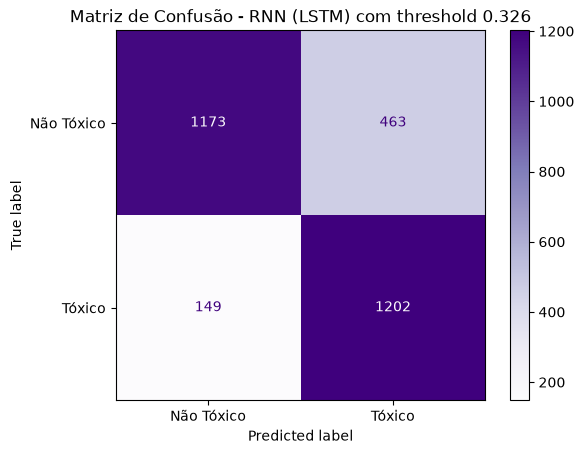

In [69]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Escolhe o threshold que maximiza o F1 da classe Tóxico
f1 = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1)
THRESHOLD = float(thresholds[best_idx])

print(f"Threshold ótimo (máximo F1): {THRESHOLD:.4f}")
print(f"F1: {f1[best_idx]:.4f} | Precisão: {precision[best_idx]:.4f} | Recall: {recall[best_idx]:.4f}")


# Report da classe Tóxico com o threshold otimizado
y_pred_tuned = (y_prob >= THRESHOLD).astype(int)
print(classification_report(y_test, y_pred_tuned, target_names=['Não Tóxico', 'Tóxico']))

# Comparação: quantos tóxicos são capturados com cada threshold
toxic_caught_050 = ((y_prob >= 0.5) & (y_test == 1)).sum()
toxic_caught_tuned = ((y_prob >= THRESHOLD) & (y_test == 1)).sum()
total_toxic = y_test.sum()
print(f"Tóxicos retidos no threshold 0.5: {toxic_caught_050}/{total_toxic} ({toxic_caught_050/total_toxic:.1%})")
print(f"Tóxicos retidos no threshold {THRESHOLD:.3f}: {toxic_caught_tuned}/{total_toxic} ({toxic_caught_tuned/total_toxic:.1%})")

# Matriz de confusão com o threshold ideal
cm_th = confusion_matrix(y_test, y_pred_tuned)
disp_th = ConfusionMatrixDisplay(confusion_matrix=cm_th, display_labels=['Não Tóxico', 'Tóxico'])
disp_th.plot(cmap=plt.cm.Purples)
plt.title(f'Matriz de Confusão - RNN (LSTM) com threshold {THRESHOLD:.3f}')
plt.show()

In [70]:
def previsao(text, threshold=THRESHOLD):
    # Pré-processamento
    tokens = preProcessar(text)
    
    # Transformar em sequência
    sequence = tokenizer_rnn.texts_to_sequences([' '.join(tokens)])
    
    # Padding
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')
    
    # Probabilidade
    probability = model.predict(padded, verbose=0)[0][0]
    
    # Classificação
    prediction = int(probability >= threshold)
    
    return prediction, probability

In [ ]:
testes = [
    "Você é um idiota!",
    "Eu gostei muito desse vídeo.",
    "Que coisa maravilhosa!",
    "Esse cara é muito burro.",
    "Não concordo com você.",
    "Vai tomar no cru.",
    "Foto horrivel, você é feio."
]

for texto in testes:
    resultado, probabilidade = previsao(texto)
    classe = "Tóxico" if resultado == 1 else "Não Tóxico"
    print(f"Texto: '{texto}' | Previsão: {classe} | Prob(Tóxico): {probabilidade:.2%}")

Texto: 'Você é um idiota!' | Previsão: Tóxico | Prob(Tóxico): 57.23%
Texto: 'Eu gostei muito desse vídeo.' | Previsão: Não Tóxico | Prob(Tóxico): 10.59%
Texto: 'Que coisa maravilhosa!' | Previsão: Não Tóxico | Prob(Tóxico): 11.38%
Texto: 'Esse cara é muito burro.' | Previsão: Tóxico | Prob(Tóxico): 59.32%
Texto: 'Não concordo com você.' | Previsão: Não Tóxico | Prob(Tóxico): 10.95%
Texto: 'Vai tomar no cru.' | Previsão: Tóxico | Prob(Tóxico): 49.30%
Texto: 'Foto horrivel, você é feio.' | Previsão: Tóxico | Prob(Tóxico): 27.67%
Texto: 'se mata seu inutil' | Previsão: Não Tóxico | Prob(Tóxico): 12.88%


In [ ]:
# Testa o modelo salvo em models/rnn_model.keras
model_salvo = tf.keras.models.load_model('../models/rnn_model.keras')
print("Modelo salvo carregado:", model_salvo.name, "\n")

for texto in testes:
    tokens = preProcessar(texto)
    sequence = tokenizer_rnn.texts_to_sequences([' '.join(tokens)])
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = model_salvo.predict(padded, verbose=0)[0][0]
    pred = int(prob >= THRESHOLD)
    classe = "Tóxico" if pred == 1 else "Não Tóxico"
    print(f"Texto: '{texto}' | Previsão: {classe} | Prob(Tóxico): {prob:.2%} | threshold {THRESHOLD:.3f}")

Modelo salvo carregado: sequential_5 

Texto: 'Você é um idiota!' | Previsão: Tóxico | Prob(Tóxico): 57.23% | threshold 0.221
Texto: 'Eu gostei muito desse vídeo.' | Previsão: Não Tóxico | Prob(Tóxico): 10.59% | threshold 0.221
Texto: 'Que coisa maravilhosa!' | Previsão: Não Tóxico | Prob(Tóxico): 11.38% | threshold 0.221
Texto: 'Esse cara é muito burro.' | Previsão: Tóxico | Prob(Tóxico): 59.32% | threshold 0.221
Texto: 'Não concordo com você.' | Previsão: Não Tóxico | Prob(Tóxico): 10.95% | threshold 0.221
Texto: 'Vai tomar no cru.' | Previsão: Tóxico | Prob(Tóxico): 49.30% | threshold 0.221
Texto: 'Foto horrivel, você é feio.' | Previsão: Tóxico | Prob(Tóxico): 27.67% | threshold 0.221
